<a href="https://colab.research.google.com/github/AdiRatnam/Hands_on_Pytorch/blob/main/W%26B_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

In [2]:
import os

print(os.listdir('/content'))

['.config', 'PlantVillage_Potato.zip', 'sample_data']


In [3]:
import zipfile

with zipfile.ZipFile('/content/PlantVillage_Potato.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
import os

print(os.listdir('/content'))

['.config', 'Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight', 'PlantVillage_Potato.zip', 'sample_data']


In [5]:
import os
import shutil
import random

source_classes = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

base_dir = "/content/PlantVillage_Potato"

for split in ["train", "val"]:
    for cls in source_classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

for cls in source_classes:

    source_folder = f"/content/{cls}"

    images = os.listdir(source_folder)

    random.shuffle(images)

    split_index = int(0.8 * len(images))

    train_images = images[:split_index]
    val_images = images[split_index:]

    for img in train_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(base_dir, "train", cls, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(base_dir, "val", cls, img)
        )

print("Done")

Done


In [6]:
print(os.listdir('/content/PlantVillage_Potato'))

['train', 'val']


In [7]:
print(os.listdir('/content/PlantVillage_Potato/train'))

['Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight']


In [8]:
mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.25, 0.25, 0.25])

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

In [9]:
data_dir = '/content/PlantVillage_Potato'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(class_names)
print(dataset_sizes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
{'train': 1721, 'val': 431}


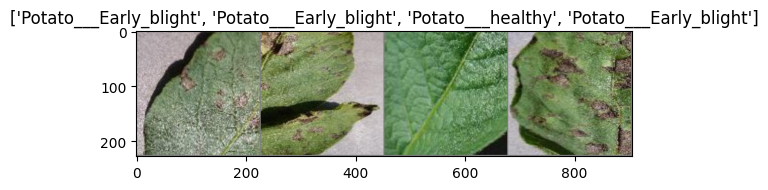

In [10]:
def imshow(inp, title):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.title(title)
    plt.show()

    # Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

#Install and Login

In [11]:
!pip install wandb -q

In [12]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ratnamadi2005 (ratnamadi2005-institute-of-engineering-and-management-ko) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
train_losses = []
val_losses = []
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0) # mul Because later we want the average loss over the whole dataset.
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step() #Multiply learning rate by 0.1 every 7 epoch, shown later

            epoch_loss = running_loss / dataset_sizes[phase]
            if phase == 'train':
              train_losses.append(epoch_loss)
            else:
              val_losses.append(epoch_loss)

            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # log added wandb
            wandb.log({f"{phase}_loss": epoch_loss,
            f"{phase}_accuracy": epoch_acc.item(),
            "epoch": epoch})

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                wandb.summary["best_val_acc"] = epoch_acc.item() #Added
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model



 Initialize an Experiment

In [22]:
# reset after every experiment
train_losses = []
val_losses = []

wandb.init(
    project="potato-disease-classification",
    name="lr_1e-4", #change in each run
    config={
        "learning_rate": 1e-4,
        "epochs": 5,
        "batch_size": 4,
        "model": "ResNet18_FineTuning"
    }
)

In [23]:
#### Finetuning the convnet ####
# Load a pretrained model and reset final fully connected layer.

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model.fc = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized Entire ResNet VVI LINE
optimizer = optim.SGD(model.parameters(), lr=0.0001) #lr change in each run

# StepLR Decays the learning rate of each parameter group by gamma every step_size epochs
# Decay LR by a factor of 0.1 every 7 epochs
# Learning rate scheduling should be applied after optimizer’s update
# e.g., you should write your code this way:
# for epoch in range(100):
#     train(...)
#     validate(...)
#     scheduler.step()

step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model = train_model(model, criterion, optimizer, step_lr_scheduler, num_epochs=5)


Epoch 0/4
----------
train Loss: 0.8654 Acc: 0.5834
val Loss: 0.7274 Acc: 0.7355

Epoch 1/4
----------
train Loss: 0.7102 Acc: 0.7298
val Loss: 0.5694 Acc: 0.8399

Epoch 2/4
----------
train Loss: 0.6273 Acc: 0.7780
val Loss: 0.4846 Acc: 0.8561

Epoch 3/4
----------
train Loss: 0.5682 Acc: 0.7937
val Loss: 0.4132 Acc: 0.8794

Epoch 4/4
----------
train Loss: 0.5185 Acc: 0.8135
val Loss: 0.3630 Acc: 0.8631

Training complete in 1m 3s
Best val Acc: 0.879350


In [24]:
wandb.finish() #finish run

epoch,▁▁▃▃▅▅▆▆██
train_accuracy,▁▅▇▇█
train_loss,█▅▃▂▁
val_accuracy,▁▆▇█▇
val_loss,█▅▃▂▁
best_val_acc,0.87935
epoch,4
train_accuracy,0.81348
train_loss,0.5185
val_accuracy,0.86311
val_loss,0.36296


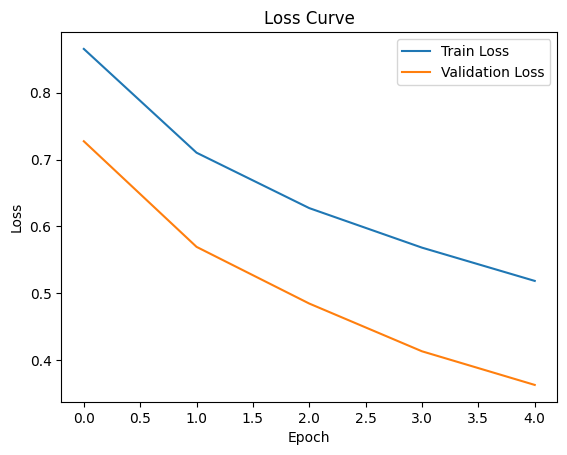

In [25]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')

plt.legend()
plt.show()